In [1]:
import pandas as pd
import numpy as np
import matplotlib as plt
from pathlib import Path

#caminhos
PASTA_RAW = Path("../data/raw")

#carregamento dos dois arquivos
clima = pd.read_csv(PASTA_RAW / "clima_mg.csv", parse_dates=['data'])
safras = pd.read_csv(PASTA_RAW / "produtividade_mg.csv")

print("=== CLIMA ===")
print(f"Linhas: {len(clima)}")
print(f"Período: {clima['data'].min()} até {clima['data'].max()}")
print(clima.dtypes)
print(clima.head())

print("\n=== SAFRAS ===")
print(safras.head())

print("\n=== SAFRAS ===")
print(f"Linhas: {len(safras)}")
print(safras.head())


=== CLIMA ===
Linhas: 9132
Período: 2000-01-01 00:00:00 até 2024-12-31 00:00:00
data                 datetime64[us]
chuva_mm                    float64
temp_max                    float64
temp_min                    float64
evapotranspiracao           float64
dtype: object
        data  chuva_mm  temp_max  temp_min  evapotranspiracao
0 2000-01-01      37.7      24.1      19.5               1.62
1 2000-01-02      39.9      22.7      19.5               1.30
2 2000-01-03      13.8      24.9      19.5               2.34
3 2000-01-04       3.1      25.0      19.3               2.37
4 2000-01-05       0.2      27.3      18.2               4.96

=== SAFRAS ===
   safra  produtividade_sc_ha
0   2001                 58.2
1   2002                 61.4
2   2003                 54.8
3   2004                 69.3
4   2005                 65.7

=== SAFRAS ===
Linhas: 24
   safra  produtividade_sc_ha
0   2001                 58.2
1   2002                 61.4
2   2003                 54.8
3   2004   

In [2]:
print(f"Total Safra: {len(safras)}")
print(f"De {safras['safra'].min()} até {safras['safra'].max()}")


Total Safra: 24
De 2001 até 2024


In [3]:
print("===VALORES FALTANDO===")
print(clima.isnull().sum())

print("\n===ESTATÍTICAS GERIS===")
print(clima.describe().round(2))

print("\n===VALORES SUSPEITOS ===")
print(f"Dias com chuva negativa : {(clima['chuva_mm'] < 0).sum()}")
print(f"Dias com temp > 45º : {(clima['temp_max'] > 45).sum()}")
print(f"Dias com temp < 0º : {(clima['temp_min'] < 0).sum()}")

===VALORES FALTANDO===
data                 0
chuva_mm             0
temp_max             0
temp_min             0
evapotranspiracao    0
dtype: int64

===ESTATÍTICAS GERIS===
                      data  chuva_mm  temp_max  temp_min  evapotranspiracao
count                 9132   9132.00   9132.00   9132.00            9132.00
mean   2012-07-01 12:00:00      3.20     26.84     17.14               4.14
min    2000-01-01 00:00:00      0.00     15.60      6.20               0.82
25%    2006-04-01 18:00:00      0.00     25.00     15.10               3.28
50%    2012-07-01 12:00:00      0.00     26.80     17.80               4.04
75%    2018-10-01 06:00:00      2.40     28.60     19.30               5.01
max    2024-12-31 00:00:00    112.00     36.40     24.50               8.00
std                    NaN      7.35      2.77      2.80               1.24

===VALORES SUSPEITOS ===
Dias com chuva negativa : 0
Dias com temp > 45º : 0
Dias com temp < 0º : 0


In [4]:
#colunas auxiliares
clima["ano"] = clima["data"].dt.year
clima["mes"] = clima["data"].dt.month

#qual safra cada dia pertence

def definir_safra(row):
    if row["mes"] >= 10:          #out/nov/dez -> safra do ano seguinte
        return row ["ano"] + 1
    elif row ["mes"] <= 3:        #jan/fev/mar -> safra do ano atual
        return row["ano"]
    else:
        return None               #abr até set -> fora da safra do milho

clima["safra"] = clima.apply(definir_safra, axis=1)

#remoção de meses fora do ciclo
clima_safra = clima.dropna(subset=["safra"]).copy()
clima_safra["safra"] = clima_safra["safra"].astype(int)

print(f"Total de dias no dataset : {len(clima)}")
print(f"Dias dentro do ciclo do milho: {len(clima_safra)}")
print(f"Safras identificadas: {clima_safra['safra'].nunique()}")
print(clima_safra["safra"].value_counts().sort_index())

Total de dias no dataset : 9132
Dias dentro do ciclo do milho: 4557
Safras identificadas: 26
safra
2000     91
2001    182
2002    182
2003    182
2004    183
2005    182
2006    182
2007    182
2008    183
2009    182
2010    182
2011    182
2012    183
2013    182
2014    182
2015    182
2016    183
2017    182
2018    182
2019    182
2020    183
2021    182
2022    182
2023    182
2024    183
2025     92
Name: count, dtype: int64


In [5]:
#Agrega por safra
resumo = clima_safra.groupby("safra").agg(
    chuva_total = ("chuva_mm",           "sum"),
    temp_media = ("temp_max",            "mean"),
    temp_min_media = ("temp_min",        "mean"),
    et0_total = ("evapotranspiracao",    "sum"),
    dias_sem_chuva = ("chuva_mm", lambda x: (x==0).sum())
).reset_index()
#remove safra do ano 2000 que está com somente 91 dias
resumo = resumo[resumo["safra"] >= 2001 & (resumo["safra"] <= 2024)].reset_index(drop=True)

print(f"Safras após limpeza: {len(resumo)}")
print(resumo["safra"].tolist())

Safras após limpeza: 26
[2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


In [6]:
clima["ano"] = clima["data"].dt.year
clima["mes"] = clima["data"].dt.month

clima_ciclo = clima[clima["mes"].isin([10, 11, 12, 1, 2, 3])].copy()

def definir_safra(row):
    if row["mes"] >= 10:
        return row["ano"] + 1
    else:
        return row["ano"]
clima_ciclo["safra"] = clima_ciclo.apply(definir_safra, axis=1)

#filtra somente safras completas
clima_ciclo = clima_ciclo[(clima_ciclo["safra"] >= 2001) & (clima_ciclo["safra"] <= 2024)]

#Agregação por safra
resumo = clima_ciclo.groupby("safra").agg(
    chuva_total = ("chuva_mm",     "sum"),
    temp_media = ("temp_max",      "mean"),
    temp_min_media = ("temp_min",  "mean"),
    et0_total = ("evapotranspiracao", "sum"),
    dias_Sem_chuva = ("chuva_mm", lambda x: (x == 0).sum())
).reset_index()

print(f"Safras: {len(resumo)}")
print(resumo["safra"].tolist())


Safras: 24
[2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


In [7]:
#União com produtividade
df = resumo.merge(safras, on="safra")

print(f"Safras com dados completos: {len(df)}")
print(df.round(2))

#Salvamento do arquivo processado
from pathlib import Path
PASTA_PROCESSED = Path("../data/processed")
PASTA_PROCESSED.mkdir(exist_ok=True)

df.to_csv(PASTA_PROCESSED / "safras_mg.csv", index = False)
print(f"\nArquivo salvo em data/processed/safras_mg.csv")

Safras com dados completos: 24
    safra  chuva_total  temp_media  temp_min_media  et0_total  dias_Sem_chuva  \
0    2001        739.7       28.31           19.08     864.35              64   
1    2002       1440.3       26.90           18.73     745.02              48   
2    2003       1223.7       28.06           19.42     813.59              66   
3    2004       1128.3       27.14           18.69     783.55              45   
4    2005       1042.7       27.73           19.14     805.67              50   
5    2006        875.4       27.89           19.23     826.55              59   
6    2007       1130.4       26.73           18.86     718.28              38   
7    2008        926.9       28.28           19.22     869.28              60   
8    2009       1361.3       27.61           19.29     784.77              52   
9    2010        951.1       27.96           19.61     809.34              47   
10   2011       1133.9       27.54           19.20     777.38              61 

In [8]:
import matplotlib.pyplot as plt
import numpy as np

#recria o resumo com dias_sem_chuva incluído
resumo = clima_ciclo.groupby("safra").agg(
    chuva_total    = ("chuva_mm",         "sum"),
    temp_media     = ("temp_max",          "mean"),
    temp_min_media = ("temp_min",          "mean"),
    et0_total      = ("evapotranspiracao", "sum"),
    dias_sem_chuva = ("chuva_mm", lambda x: (x == 0).sum())
).reset_index()

#refaz o merge
df = resumo.merge(safras, on="safra")

#salva atualizado
df.to_csv("../data/processed/safras_mg.csv", index=False)
print(f"Dataset atualizado: {len(df)} safras, {len(df.columns)} colunas")
print(df.columns.tolist())

Dataset atualizado: 24 safras, 7 colunas
['safra', 'chuva_total', 'temp_media', 'temp_min_media', 'et0_total', 'dias_sem_chuva', 'produtividade_sc_ha']


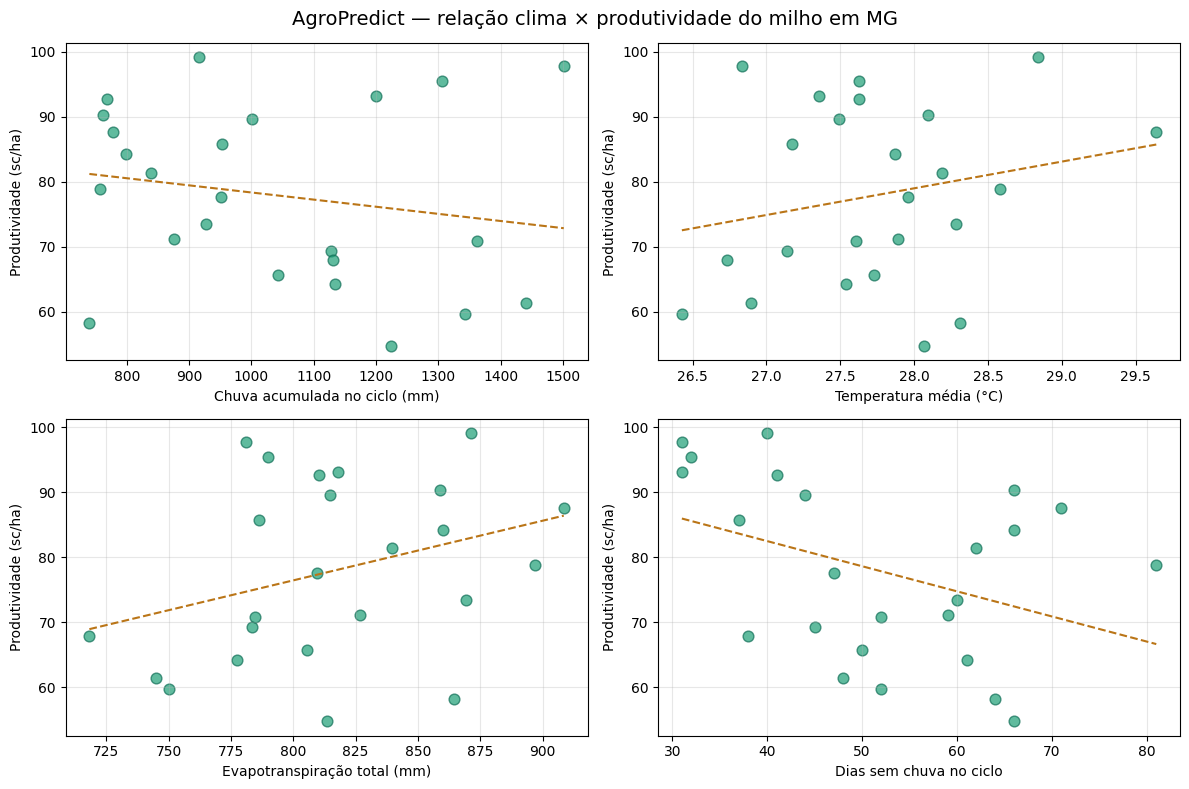

Gráfico salvo!


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("AgroPredict — relação clima × produtividade do milho em MG",
             fontsize=14)

variaveis = [
    ("chuva_total",    "Chuva acumulada no ciclo (mm)"),
    ("temp_media",     "Temperatura média (°C)"),
    ("et0_total",      "Evapotranspiração total (mm)"),
    ("dias_sem_chuva", "Dias sem chuva no ciclo"),
]

for ax, (col, titulo) in zip(axes.flatten(), variaveis):
    ax.scatter(df[col], df["produtividade_sc_ha"],
               color="#1D9E75", alpha=0.7, edgecolors="#0F6E56", s=60)

    # linha de tendência com proteção contra erro
    try:
        z = np.polyfit(df[col], df["produtividade_sc_ha"], 1)
        p = np.poly1d(z)
        x_line = np.linspace(df[col].min(), df[col].max(), 100)
        ax.plot(x_line, p(x_line), "--", color="#BA7517", linewidth=1.5)
    except Exception as e:
        print(f"Linha de tendência não gerada para {col}: {e}")

    ax.set_xlabel(titulo, fontsize=10)
    ax.set_ylabel("Produtividade (sc/ha)", fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/exploracao_clima_produtividade.png", dpi=150)
plt.show()
print("Gráfico salvo!")


In [10]:
print("===CORRELAÇÃO COM PRODUTIVIDADE===\n")

colunas = ["chuva_total", "temp_media", "et0_total", "dias_sem_chuva"]

for col in colunas:
    corr = df[col].corr(df["produtividade_sc_ha"])
    sinal = "positiva" if corr > 0 else "negativa"
    forca = "forte" if abs(corr) > 0.6 else "moderada" if abs(corr) > 0.3 else "fraca"
    print(f"{col:20s}: {corr:+.3f} ({forca} {sinal})")

===CORRELAÇÃO COM PRODUTIVIDADE===

chuva_total         : -0.190 (fraca negativa)
temp_media          : +0.217 (fraca positiva)
et0_total           : +0.325 (moderada positiva)
dias_sem_chuva      : -0.391 (moderada negativa)


In [11]:
import numpy as np

#cria uma variável que representa a tendência tecnológica ao longo dos anos
df["tendencia"] = df["safra"] - df["safra"].min()

#recalcula as correlações
print("=== CORRELAÇÃO CORRIGIDA APÓS REMOÇÃO DA TENDÊNCIA TECNOLÓGICA ===\n")

colunas = ["chuva_total", "temp_media", "et0_total", "dias_sem_chuva", "tendencia"]

for col in colunas:
    corr = df[col].corr(df["produtividade_sc_ha"])
    sinal = "positiva" if corr > 0 else "negativa"
    forca = "forte" if abs(corr) > 0.6 else "moderada" if abs(corr) < 0.3 else "fraca"
    print(f"{col:20s}: {corr:+.3f} ({forca} {sinal})")

=== CORRELAÇÃO CORRIGIDA APÓS REMOÇÃO DA TENDÊNCIA TECNOLÓGICA ===

chuva_total         : -0.190 (moderada negativa)
temp_media          : +0.217 (moderada positiva)
et0_total           : +0.325 (fraca positiva)
dias_sem_chuva      : -0.391 (fraca negativa)
tendencia           : +0.916 (forte positiva)


In [12]:
df.to_csv("../data/processed/safras_mg.csv", index=False)

print("Dataset final salvo!")
print(f"Colunas disponíveis: {df.columns.tolist()}")
print(f"Safras: {len(df)}")
print(df.round(2))

Dataset final salvo!
Colunas disponíveis: ['safra', 'chuva_total', 'temp_media', 'temp_min_media', 'et0_total', 'dias_sem_chuva', 'produtividade_sc_ha', 'tendencia']
Safras: 24
    safra  chuva_total  temp_media  temp_min_media  et0_total  dias_sem_chuva  \
0    2001        739.7       28.31           19.08     864.35              64   
1    2002       1440.3       26.90           18.73     745.02              48   
2    2003       1223.7       28.06           19.42     813.59              66   
3    2004       1128.3       27.14           18.69     783.55              45   
4    2005       1042.7       27.73           19.14     805.67              50   
5    2006        875.4       27.89           19.23     826.55              59   
6    2007       1130.4       26.73           18.86     718.28              38   
7    2008        926.9       28.28           19.22     869.28              60   
8    2009       1361.3       27.61           19.29     784.77              52   
9    2010    

In [13]:
clima["ano"] = clima["data"].dt.year
clima["mes"] = clima["data"].dt.month

clima_ciclo = clima[clima["mes"].isin([10, 11, 12, 1, 2, 3])].copy()

def definir_safra(row):
    if row["mes"] >= 10:
        return row["ano"] + 1
    else:
        return row["ano"]

clima_ciclo["safra"] = clima_ciclo.apply(definir_safra, axis=1)

#filtrar safras completas
clima_ciclo = clima_ciclo[(clima_ciclo["safra"] >= 2001) & (clima_ciclo["safra"] <= 2024)]

#agregar por safra
resumo = clima_ciclo.groupby("safra").agg(
    chuva_total = ("chuva_mm", "sum"),
    temp_media = ("temp_max", "mean"),
    temp_min_media = ("temp_min", "mean"),
    et0_total = ("evapotranspiracao", "sum"),
    dias_sem_chuva = ("chuva_mm", lambda x: (x == 0).sum())
).reset_index()

#unir com produtividade
df = resumo.merge(safras, on="safra")

#adiciona tendência tecnológica
df["tendencia"] = df["safra"] - df["safra"].min()

#salva atualizado
from pathlib import Path
PASTA_PROCESSED = Path("../data/processed")
PASTA_PROCESSED.mkdir(exist_ok=True)
df.to_csv(PASTA_PROCESSED / "safras_mg.csv", index=False)

print(f"Safras: {len(df)}")
print(f"Colunas: {df.columns.tolist()}")
print(df.round(2))



Safras: 24
Colunas: ['safra', 'chuva_total', 'temp_media', 'temp_min_media', 'et0_total', 'dias_sem_chuva', 'produtividade_sc_ha', 'tendencia']
    safra  chuva_total  temp_media  temp_min_media  et0_total  dias_sem_chuva  \
0    2001        739.7       28.31           19.08     864.35              64   
1    2002       1440.3       26.90           18.73     745.02              48   
2    2003       1223.7       28.06           19.42     813.59              66   
3    2004       1128.3       27.14           18.69     783.55              45   
4    2005       1042.7       27.73           19.14     805.67              50   
5    2006        875.4       27.89           19.23     826.55              59   
6    2007       1130.4       26.73           18.86     718.28              38   
7    2008        926.9       28.28           19.22     869.28              60   
8    2009       1361.3       27.61           19.29     784.77              52   
9    2010        951.1       27.96           1